# DBA Reference Builder สำหรับสระภาษาไทย
สร้าง mean RMS energy curve ด้วย **DTW Barycenter Averaging (DBA)**  
ผลลัพธ์คือไฟล์ `.npy` ต่อสระ → ใช้ใน `vowelserver.py` แทน single reference `.wav`

## 0. Install Dependencies

In [ ]:
!pip install tslearn librosa fastdtw matplotlib numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 17.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.66.0 which is incompatible.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.font_manager as fm
import urllib.request
from pydub import AudioSegment
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Config — แก้ path ตรงนี้

In [ ]:
import os

DATA_ROOT   = "/content/drive/My Drive/dataset"
OUTPUT_DIR  = "/content/drive/MyDrive/references_dba"
SR          = 16000

VOWEL_FOLDERS = [
    '01','02','03','04','05','06','07','08','09',
    's1','s2','s3','s4','s5','s6','s7','s8','s9'
]
VOWEL_THAI = [
    'อา','อี','อือ','อู','เอ','แอ','โอ','ออ','เออ',
    'อะ','อิ','อึ','อุ','เอะ','แอะ','โอะ','เอาะ','เออะ'
]

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output dir:", OUTPUT_DIR)

Output dir: /content/drive/MyDrive/references_dba


## 2. Helper Functions

In [ ]:
import numpy as np
import librosa
import glob

def get_rms_curve(path, sr=16000):
    y, _ = librosa.load(path, sr=sr, mono=True)
    rms = librosa.feature.rms(y=y).flatten().astype(np.float64)
    max_val = np.max(rms)
    if max_val > 0:
        rms = rms / max_val
    return rms

def smart_crop(y, sr=16000, window_ms=500):
    frame_length = 512
    hop_length = 512
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length).flatten()
    peak_frame = np.argmax(rms)
    peak_sample = peak_frame * hop_length
    half_window = int((window_ms / 1000) * sr // 2)
    start = max(0, peak_sample - half_window)
    end = min(len(y), peak_sample + half_window)
    return y[start:end]

def load_curves_for_vowel(folder, use_smart_crop=True):
    pattern = os.path.join(DATA_ROOT, folder, "*.wav")
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"  ⚠️  ไม่พบไฟล์ใน {pattern}")
        return [], []
    curves = []
    for f in files:
        y, _ = librosa.load(f, sr=SR, mono=True)
        if use_smart_crop:
            y = smart_crop(y, SR)
        rms = librosa.feature.rms(y=y).flatten().astype(np.float64)
        max_val = np.max(rms)
        if max_val > 0:
            rms = rms / max_val
        curves.append(rms)

    return curves, files

print("Helper functions loaded ✓")

Helper functions loaded ✓


## 3. ตรวจสอบข้อมูล — ดูจำนวนไฟล์ต่อสระ

In [ ]:
print(f"{'Folder':<8} {'Thai':<6} {'Files':>6}")
print("-" * 24)
for folder, thai in zip(VOWEL_FOLDERS, VOWEL_THAI):
    pattern = os.path.join(DATA_ROOT, folder, "*.wav")
    n = len(glob.glob(pattern))
    status = "✓" if n > 0 else "✗"
    print(f"{folder:<8} {thai:<6} {n:>5}  {status}")

Folder   Thai    Files
------------------------
01       อา       100  ✓
02       อี       100  ✓
03       อือ      100  ✓
04       อู       100  ✓
05       เอ       100  ✓
06       แอ       100  ✓
07       โอ       100  ✓
08       ออ       100  ✓
09       เออ      100  ✓
s1       อะ       100  ✓
s2       อิ       100  ✓
s3       อึ       100  ✓
s4       อุ       100  ✓
s5       เอะ      100  ✓
s6       แอะ      100  ✓
s7       โอะ      100  ✓
s8       เอาะ     100  ✓
s9       เออะ     100  ✓


## 4. สร้าง DBA Reference ทุกสระ

In [ ]:
from tslearn.barycenters import dtw_barycenter_averaging

dba_results = {}
for folder, thai in zip(VOWEL_FOLDERS, VOWEL_THAI):
    print(f"Processing {folder} ({thai})...", end=" ")

    curves, files = load_curves_for_vowel(folder)
    if not curves:
        continue


    max_len = max(len(c) for c in curves)
    padded = np.array([
        np.pad(c, (0, max_len - len(c)), mode='constant') for c in curves
    ])


    X = padded[:, :, np.newaxis]
    dba_curve = dtw_barycenter_averaging(X)
    dba_flat = dba_curve.flatten()


    if np.max(dba_flat) > 0:
        dba_flat = dba_flat / np.max(dba_flat)

    dba_results[folder] = dba_flat


    out_path = os.path.join(OUTPUT_DIR, f"{folder}_dba.npy")
    np.save(out_path, dba_flat)
    print(f"saved ({len(files)} files, len={len(dba_flat)}) ✓")

print("\nDone! ทุกสระถูก save แล้ว")

Processing 01 (อา)... saved (100 files, len=16) ✓
Processing 02 (อี)... saved (100 files, len=16) ✓
Processing 03 (อือ)... saved (100 files, len=16) ✓
Processing 04 (อู)... saved (100 files, len=16) ✓
Processing 05 (เอ)... saved (100 files, len=16) ✓
Processing 06 (แอ)... saved (100 files, len=16) ✓
Processing 07 (โอ)... saved (100 files, len=16) ✓
Processing 08 (ออ)... saved (100 files, len=16) ✓
Processing 09 (เออ)... saved (100 files, len=16) ✓
Processing s1 (อะ)... saved (100 files, len=16) ✓
Processing s2 (อิ)... saved (100 files, len=9) ✓
Processing s3 (อึ)... saved (100 files, len=15) ✓
Processing s4 (อุ)... saved (100 files, len=14) ✓
Processing s5 (เอะ)... saved (100 files, len=13) ✓
Processing s6 (แอะ)... saved (100 files, len=15) ✓
Processing s7 (โอะ)... saved (100 files, len=13) ✓
Processing s8 (เอาะ)... saved (100 files, len=13) ✓
Processing s9 (เออะ)... saved (100 files, len=13) ✓

Done! ทุกสระถูก save แล้ว


## 5. Visualize DBA Curves — ดูหน้าตา curve แต่ละสระ

In [ ]:
import urllib.request
import os

font_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
font_path = "Sarabun-Regular.ttf"

# Download the font file if it doesn't exist
if not os.path.exists(font_path):
    print(f"Downloading {font_path}...")
    urllib.request.urlretrieve(font_url, font_path)
    print("Download complete.")
else:
    print(f"{font_path} already exists.")

Download complete.


In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Add the font to Matplotlib's font manager
fm.fontManager.addfont(font_path)

# Set the font globally
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['font.sans-serif'] = ['Sarabun', 'Tahoma', 'DejaVu Sans']
print("Matplotlib font configured for Sarabun.")

Matplotlib font configured for Sarabun.


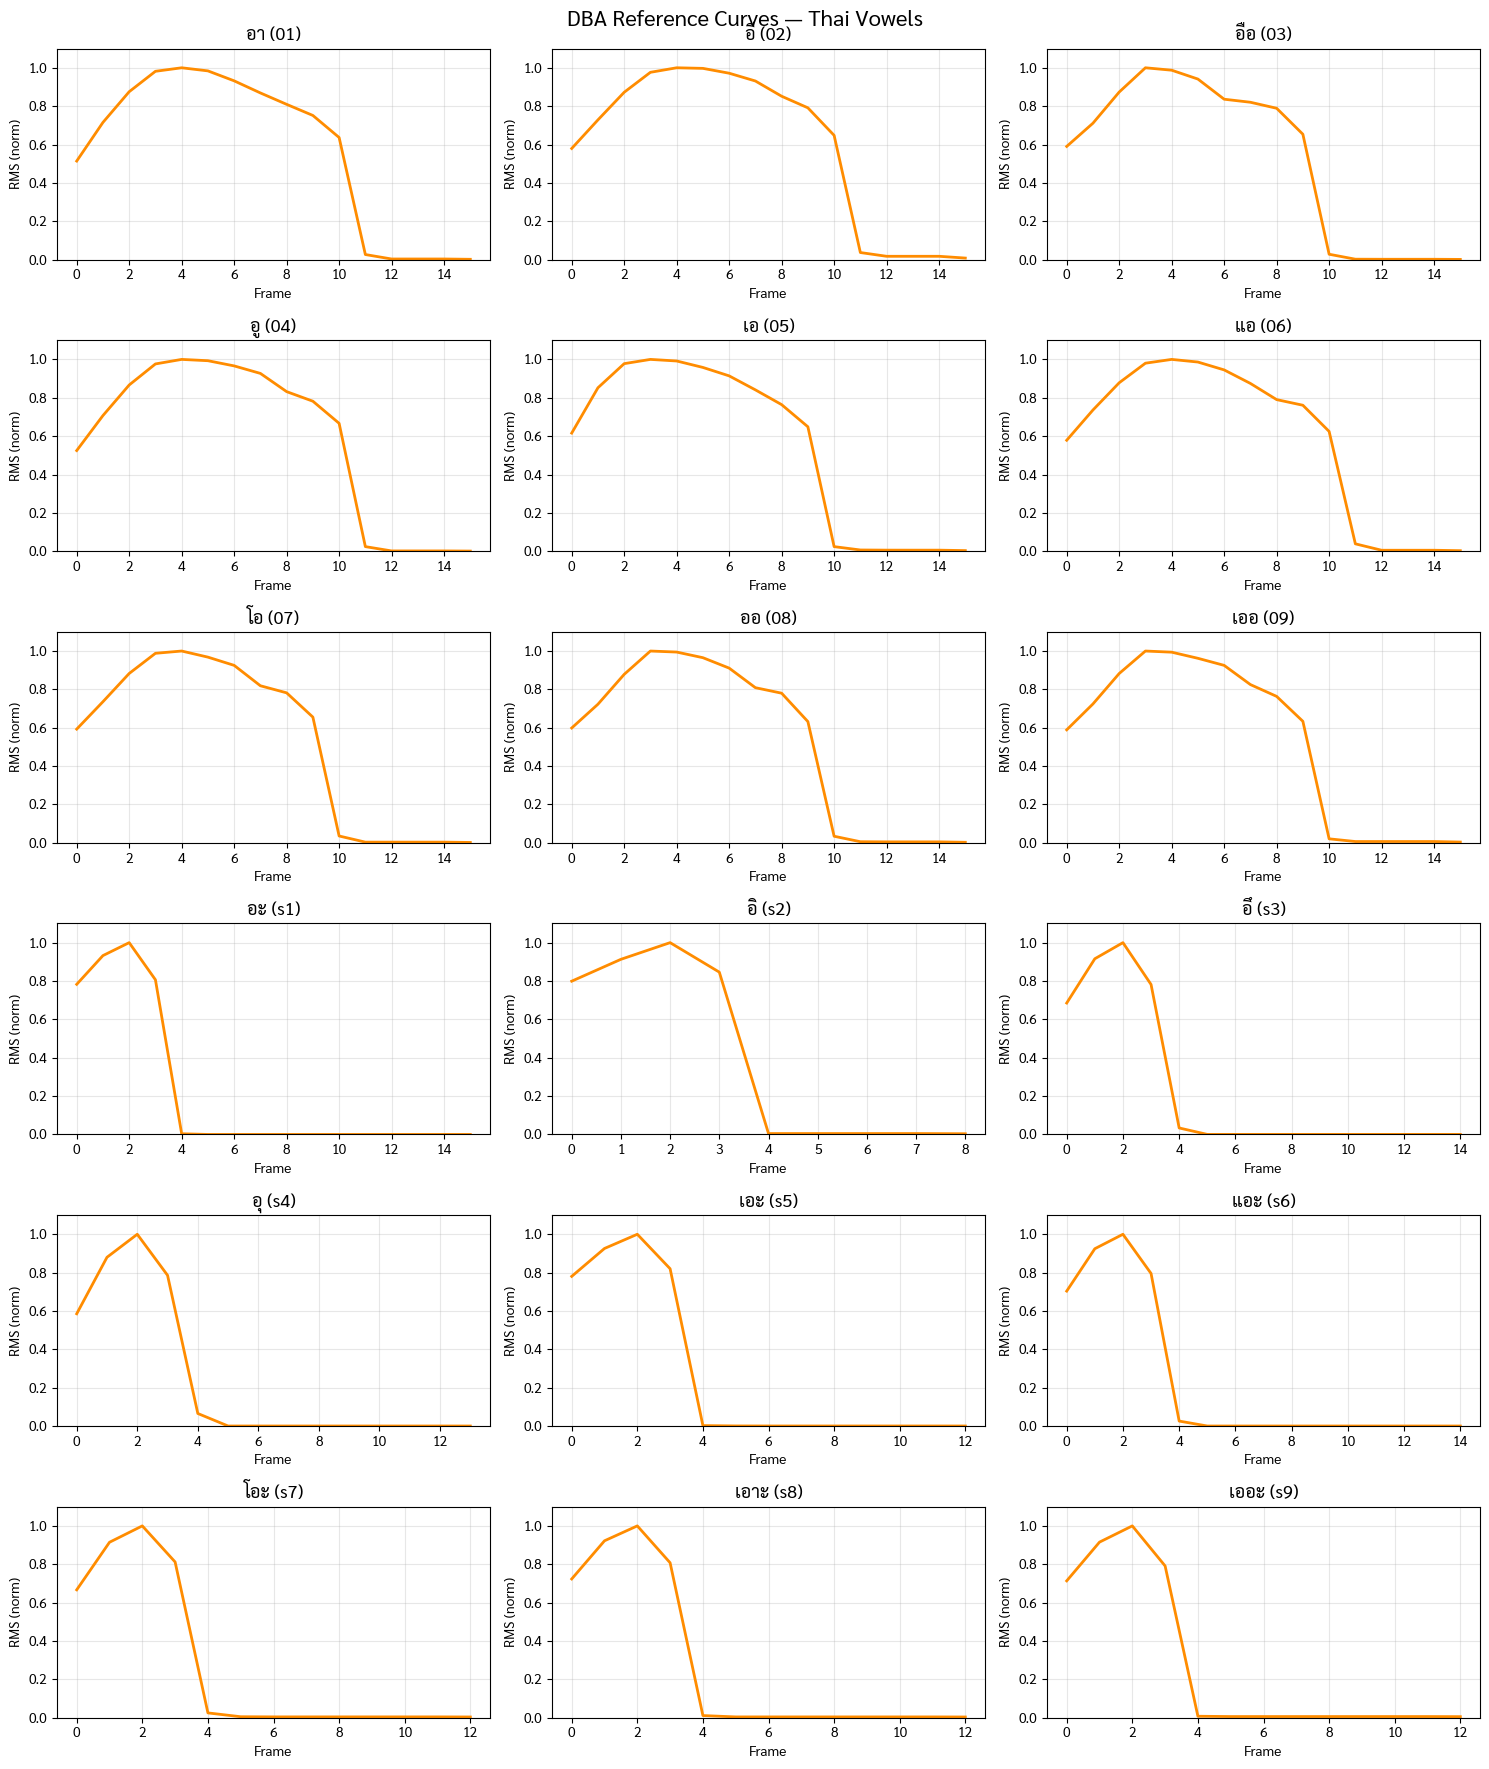

Saved overview plot


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Sarabun'  # ใช้ Sarabun แทน TH Sarabun New

n_cols = 3
n_rows = -(-len(dba_results) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, (folder, curve) in enumerate(dba_results.items()):
    thai = VOWEL_THAI[VOWEL_FOLDERS.index(folder)]
    axes[i].plot(curve, color='darkorange', linewidth=2)
    axes[i].set_title(f"{thai} ({folder})", fontsize=13)
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xlabel("Frame")
    axes[i].set_ylabel("RMS (norm)")
    axes[i].grid(True, alpha=0.3)

# ซ่อน axes ที่เหลือ
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("DBA Reference Curves — Thai Vowels", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "dba_curves_overview.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved overview plot")

## 6. เปรียบ DBA vs Individual Samples (สระใดสระหนึ่ง)

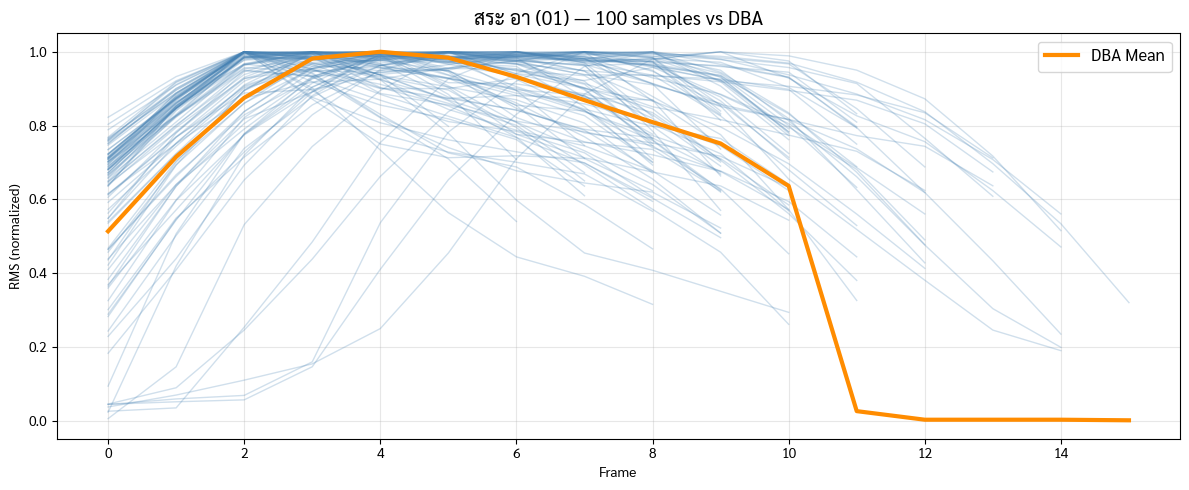

In [ ]:
INSPECT_FOLDER = '01'  # ← เปลี่ยนสระที่อยากดูได้

curves, files = load_curves_for_vowel(INSPECT_FOLDER)
dba_curve = dba_results[INSPECT_FOLDER]
thai_label = VOWEL_THAI[VOWEL_FOLDERS.index(INSPECT_FOLDER)]

plt.figure(figsize=(12, 5))

# Plot individual samples (จาง)
for c in curves:
    plt.plot(c, color='steelblue', alpha=0.25, linewidth=1)

# Plot DBA (เข้ม)
plt.plot(dba_curve, color='darkorange', linewidth=3, label='DBA Mean')

plt.title(f"สระ {thai_label} ({INSPECT_FOLDER}) — {len(curves)} samples vs DBA", fontsize=14)
plt.xlabel("Frame")
plt.ylabel("RMS (normalized)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7. Summary — ไฟล์ที่สร้าง

In [ ]:
saved = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*_dba.npy")))
print(f"{'File':<25} {'Length':>8} {'Max':>8} {'Min':>8}")
print("-" * 52)
for f in saved:
    arr = np.load(f)
    print(f"{os.path.basename(f):<25} {len(arr):>8} {np.max(arr):>8.4f} {np.min(arr):>8.4f}")

print(f"\nTotal: {len(saved)} files saved to {OUTPUT_DIR}")
print("\n✅ นำไปใช้ใน vowelserver.py ได้เลย:")
print("   dba_path = f'references/{vowel_names[class_id]}_dba.npy'")
print("   model_energy = np.load(dba_path)")

File                        Length      Max      Min
----------------------------------------------------
01_dba.npy                      16   1.0000   0.0016
02_dba.npy                      16   1.0000   0.0080
03_dba.npy                      16   1.0000   0.0011
04_dba.npy                      16   1.0000   0.0008
05_dba.npy                      16   1.0000   0.0033
06_dba.npy                      16   1.0000   0.0028
07_dba.npy                      16   1.0000   0.0021
08_dba.npy                      16   1.0000   0.0030
09_dba.npy                      16   1.0000   0.0042
s1_dba.npy                      16   1.0000   0.0002
s2_dba.npy                       9   1.0000   0.0038
s3_dba.npy                      15   1.0000   0.0003
s4_dba.npy                      14   1.0000   0.0004
s5_dba.npy                      13   1.0000   0.0005
s6_dba.npy                      15   1.0000   0.0004
s7_dba.npy                      13   1.0000   0.0038
s8_dba.npy                      13   1.0000   